연령 : age

성별 : sex 
(1: 남자, 2:여자)

흡연 여부 : BS3_1
(1: 매일피움, 2: 가끔, 3: 과거에는 피웠으나, 현재 피우지 않음, 0: 비해당)

음주 빈도 : BD1_11 
(1: 최근 1년간 전혀 마시지 않았다, 2: 월1회미만, 3: 월1회정도, 4: 월2~4회, 5: 주2~3회정도, 6: 주4회이상, 0: 비해당)

칫솔질 여부 : BMI_1 ~ 8 
(0: 아니오, 1: 예, 0: 비해당(칫솔질 안했음))

구강용품 : BM2_1 ~ 5 
(0:아니오, 1: 예, 0: 비해당(12세미만))

구강검진(정기검진) : OR1_2
(0: 아니오, 1: 예)

당뇨여부 : DE1_dg 
(0: 없음, 1: 있음)

치주질환여부 : NO_CPI_34 
(0: 아니오, 1: 예)

우울증 여부 : DF2_pr
(0: 없음, 1: 있음)

평소 스트레스 인지 정도 : BP1 
(1. 대단히 많이 느낀다, 2. 많이 느끼는 편이다, 3. 조금 느끼는 편이다, 4. 거의 느끼지 않는다.)

비만 여부 : HE_BMI
(1. 저체중, 2. 정상, 3. 비만)

주중 하루 평균 수면시간 : Total_slp_wk 
(()분, 8888. 비해당(소아), 9999. 모름, 무응답) ** 8888, 9999값 삭제

주말 하루 평균 수면시간 : Total_slp_wd
(()분, 8888. 비해당(소아), 9999. 모름, 무응답) ** 8888, 9999값 삭제


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('양치전처리.csv')
df.head(10)

# columns : 18 , row : 11898
# target : NO_CPI_34 [치주질환 여부]

,NO_CPI_34,age,sex,BS3_1,DE1_dg,BD1_11,OR1_2,DF2_pr,BP1,Total_slp_wk,Total_slp_wd,BM1,BM2_1,BM2_2,BM2_3,BM2_4,BM2_5,HE_BMI
0,0.0,80.0,2.0,4.0,0.0,4.0,0.0,0.0,4.0,600.0,600.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0
1,0.0,59.0,2.0,4.0,0.0,2.0,1.0,0.0,3.0,420.0,360.0,4.0,1.0,1.0,1.0,0.0,0.0,2.0
2,0.0,68.0,1.0,1.0,0.0,6.0,0.0,0.0,3.0,510.0,510.0,3.0,0.0,0.0,1.0,0.0,0.0,2.0
3,0.0,64.0,2.0,4.0,1.0,0.0,1.0,0.0,3.0,240.0,240.0,2.0,1.0,1.0,0.0,0.0,0.0,3.0
4,0.0,77.0,1.0,3.0,1.0,2.0,0.0,0.0,4.0,480.0,480.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0
5,1.0,68.0,2.0,4.0,0.0,0.0,0.0,0.0,4.0,360.0,300.0,2.0,0.0,0.0,1.0,0.0,0.0,3.0
6,1.0,66.0,1.0,3.0,0.0,2.0,0.0,0.0,3.0,480.0,480.0,3.0,0.0,0.0,0.0,0.0,0.0,2.0
7,0.0,60.0,2.0,4.0,0.0,2.0,1.0,0.0,3.0,600.0,660.0,3.0,1.0,0.0,0.0,0.0,0.0,3.0
8,1.0,47.0,1.0,4.0,0.0,5.0,1.0,0.0,3.0,300.0,420.0,2.0,1.0,0.0,0.0,0.0,0.0,2.0
9,0.0,45.0,2.0,4.0,0.0,3.0,0.0,0.0,2.0,390.0,540.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0


In [3]:
# 디폴트 값

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. 특성(X)과 타겟(y) 분리
# target : NO_CPI_34 [치주질환 여부]
X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

# 2. 학습 데이터와 테스트 데이터 분리 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Decision Tree 모델 생성 및 학습 (하이퍼파라미터는 디폴트)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 4. 예측 수행
y_pred = dt_model.predict(X_test)

# 5. 결과 출력 (Accuracy, Precision, Recall, F1-score)
print("--- Decision Tree Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

--- Decision Tree Model Performance ---
Accuracy: 0.6437

Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.73      0.74      1659
         1.0       0.43      0.46      0.44       746

    accuracy                           0.64      2405
   macro avg       0.59      0.59      0.59      2405
weighted avg       0.65      0.64      0.65      2405



In [5]:
# 지니계수 대신 엔트로피 사용

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# 방법 1: 정보 이득(Entropy)과 가지치기(Pruning) 적용
# max_depth: 나무의 최대 깊이를 제한하여 과적합 방지
# min_samples_leaf: 리프 노드가 되기 위한 최소 샘플 수 설정
dt_improved = DecisionTreeClassifier(
    criterion='entropy',    # 지니 계수 대신 엔트로피 사용
    max_depth=7,            # 나무의 깊이 제한 (데이터에 따라 5~10 사이 권장)
    min_samples_leaf=10,    # 한 노드에 최소 10개 샘플이 있어야 분리 가능
    random_state=42,
    class_weight='balanced' # 불균형한 데이터 비율(2:1)을 모델이 인지하도록 설정
)

dt_improved.fit(X_train, y_train)
y_pred_improved = dt_improved.predict(X_test)

# 결과 출력
print("--- Improved Decision Tree Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_improved):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_improved))

--- Improved Decision Tree Performance ---
Accuracy: 0.6216

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.54      0.66      1659
         1.0       0.44      0.80      0.57       746

    accuracy                           0.62      2405
   macro avg       0.65      0.67      0.62      2405
weighted avg       0.73      0.62      0.63      2405



In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# 모든 마디가 순수마디가 될 때까지 분할하도록 설정
# 하이퍼파라미터를 디폴트(None)로 설정하면 순수해질 때까지 분기합니다.
dt_overfitted = DecisionTreeClassifier(
    criterion='entropy',    # 엔트로피 기준 유지
    max_depth=None,         # 깊이 제한 없음 (순수해질 때까지 성장)
    min_samples_split=2,    # 최소 2개만 있어도 분할 진행
    min_samples_leaf=1,     # 리프 노드에 샘플이 1개만 있어도 인정 (순수 마디 보장)
    random_state=42
)

# 모델 학습
dt_overfitted.fit(X_train, y_train)

# 예측 수행
y_pred_train = dt_overfitted.predict(X_train) # 학습 데이터에 대한 예측
y_pred_test = dt_overfitted.predict(X_test)   # 테스트 데이터에 대한 예측

# 결과 출력
print("--- Overfitted Decision Tree Performance (Test Set) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test))

# 과적합 확인을 위한 학습 데이터 성능 확인
print("\n" + "="*50)
print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print("학습 데이터 정확도가 1.0(100%)에 가깝다면 모든 마디가 순수마디로 분할된 것입니다.")

--- Overfitted Decision Tree Performance (Test Set) ---
Accuracy: 0.6499

Classification Report (Test Set):
              precision    recall  f1-score   support

         0.0       0.75      0.73      0.74      1659
         1.0       0.44      0.47      0.45       746

    accuracy                           0.65      2405
   macro avg       0.60      0.60      0.60      2405
weighted avg       0.66      0.65      0.65      2405


Train Accuracy: 0.9992
학습 데이터 정확도가 1.0(100%)에 가깝다면 모든 마디가 순수마디로 분할된 것입니다.


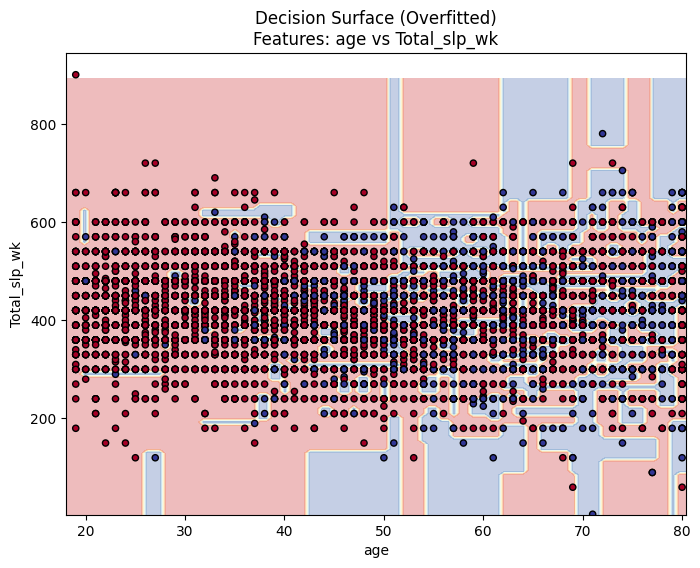

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def plot_overfitted_surface(clf, X, y):
    # 시각화를 위해 중요도가 높은 상위 2개 특성 인덱스 추출 (예: age, Total_slp_wk)
    # 여기서는 예시로 첫 두 개의 컬럼을 사용하거나, 위에서 구한 중요도 순으로 선택합니다.
    top_2_features = feature_importance_df['Feature'].values[:2]
    X_vis = X[top_2_features].values
    
    # 시각화용 모델 재학습 (2개 변수만 사용)
    clf_vis = DecisionTreeClassifier(criterion='entropy', random_state=42).fit(X_vis, y)

    x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
    y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, (x_max-x_min)/100),
                         np.arange(y_min, y_max, (y_max-y_min)/100))

    Z = clf_vis.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, s=20, edgecolor='k', cmap='RdYlBu')
    
    plt.title(f"Decision Surface (Overfitted)\nFeatures: {top_2_features[0]} vs {top_2_features[1]}")
    plt.xlabel(top_2_features[0])
    plt.ylabel(top_2_features[1])
    plt.show()

# 차트 실행
plot_overfitted_surface(dt_overfitted, X_train, y_train)

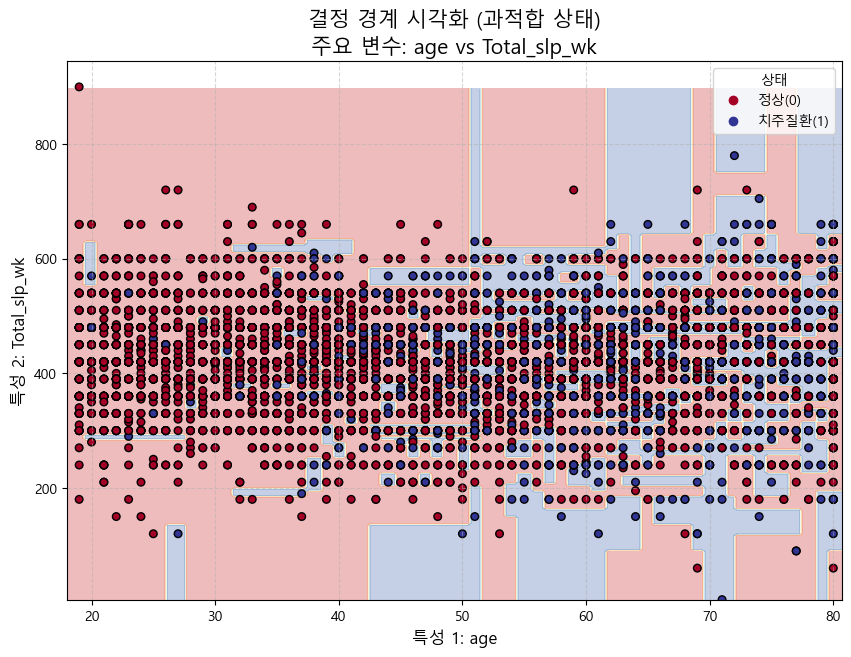

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
import platform

# 1. 한글 폰트 설정 (환경에 맞게 자동 설정)
if platform.system() == 'Windows':
    rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    rc('font', family='AppleGothic')
else: # Linux/Colab
    rc('font', family='NanumBarunGothic')
    
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

def plot_overfitted_surface_kr(clf, X, y):
    # 특성 중요도 데이터프레임이 미리 계산되어 있어야 합니다.
    # 상위 2개 특성 추출 (예: age, Total_slp_wk)
    top_2_features = feature_importance_df['Feature'].values[:2]
    X_vis = X[top_2_features].values
    
    # 시각화용 모델 재학습 (2개 변수만 사용하여 평면에 그림)
    clf_vis = DecisionTreeClassifier(criterion='entropy', random_state=42).fit(X_vis, y)

    # 그리드 영역 설정
    x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
    y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
    
    # 해상도를 조절 (100 -> 200으로 높이면 더 세밀하게 보입니다)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, (x_max-x_min)/200),
                         np.arange(y_min, y_max, (y_max-y_min)/200))

    # 예측 및 결과 리셰이프
    Z = clf_vis.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 7))
    
    # 결정 경계면 그리기
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    
    # 실제 데이터 산점도 그리기
    scatter = plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, s=30, edgecolor='k', cmap='RdYlBu')
    
    # 한글 제목 및 라벨 설정
    plt.title(f"결정 경계 시각화 (과적합 상태)\n주요 변수: {top_2_features[0]} vs {top_2_features[1]}", fontsize=15)
    plt.xlabel(f"특성 1: {top_2_features[0]}", fontsize=12)
    plt.ylabel(f"특성 2: {top_2_features[1]}", fontsize=12)
    
    # 범례 추가 (0: 정상, 1: 질환)
    handles, labels = scatter.legend_elements()
    plt.legend(handles, ['정상(0)', '치주질환(1)'], loc="upper right", title="상태")
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# 차트 실행
plot_overfitted_surface_kr(dt_overfitted, X_train, y_train)

In [12]:
## gridsearchCV를 통해 최적의 max_depth 찾기

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# 1. 모델 설정 (튜닝할 하이퍼파라미터 정의)
dt_clf = DecisionTreeClassifier(criterion='entropy', random_state=42, class_weight='balanced')

# 2. 탐색할 파라미터 그리드 설정
# max_depth뿐만 아니라 다른 가지치기 파라미터도 함께 넣으면 더 정교해집니다.
param_grid = {
    'max_depth': range(3, 16),               # 3부터 15까지 탐색
    'min_samples_split': [2, 5, 10],         # 분할을 위한 최소 샘플 수
    'min_samples_leaf': [1, 5, 10]           # 리프 노드가 되기 위한 최소 샘플 수
}

# 3. GridSearchCV 실행 (5-Fold 교차 검증)
grid_cv = GridSearchCV(dt_clf, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_cv.fit(X_train, y_train)

# 4. 최적 결과 출력
print(f"최적의 하이퍼파라미터: {grid_cv.best_params_}")
print(f"최고 F1-Score: {grid_cv.best_score_:.4f}")

# 5. 최적의 모델로 예측 수행
best_dt = grid_cv.best_estimator_
y_pred_best = best_dt.predict(X_test)

print("\n--- Optimized Decision Tree Performance ---")
print(classification_report(y_test, y_pred_best))

최적의 하이퍼파라미터: {'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 2}
최고 F1-Score: 0.5777

--- Optimized Decision Tree Performance ---
              precision    recall  f1-score   support

         0.0       0.87      0.56      0.68      1659
         1.0       0.45      0.81      0.58       746

    accuracy                           0.64      2405
   macro avg       0.66      0.69      0.63      2405
weighted avg       0.74      0.64      0.65      2405



시각화에 사용된 상위 2개 변수: age, BS3_1


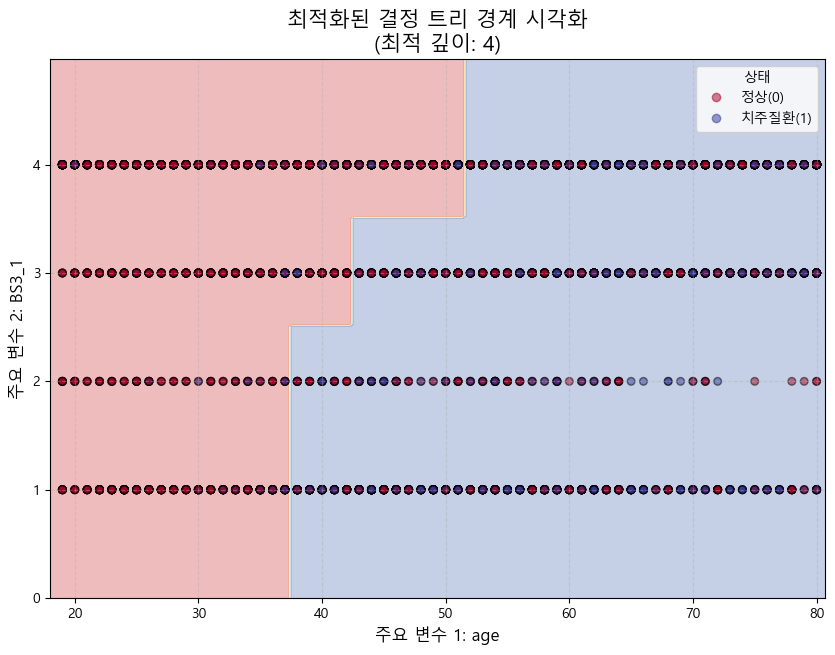

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

def plot_best_decision_surface(best_model, X, y):
    # 1. 모델에서 특성 중요도 추출 후 상위 2개 변수 선정
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    top_2_indices = indices[:2]
    top_2_features = X.columns[top_2_indices]
    
    print(f"시각화에 사용된 상위 2개 변수: {top_2_features[0]}, {top_2_features[1]}")

    # 2. 시각화용 데이터 추출
    X_vis = X[top_2_features].values
    
    # 3. 최적의 하이퍼파라미터로 시각화용 모델 재학습 (2개 변수 전용)
    # GridSearchCV로 찾은 최적의 파라미터를 그대로 적용합니다.
    params = best_model.get_params()
    vis_model = DecisionTreeClassifier(**params).fit(X_vis, y)

    # 4. 그리드 영역 설정
    x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
    y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, (x_max-x_min)/200),
                         np.arange(y_min, y_max, (y_max-y_min)/200))

    # 5. 예측 및 차트 그리기
    Z = vis_model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 7))
    
    # 결정 경계면 (일반화된 경계)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    
    # 실제 데이터 산점도 (투명도 조절로 겹침 확인)
    scatter = plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, s=30, 
                        edgecolor='k', cmap='RdYlBu', alpha=0.5)
    
    # 한국어 라벨링
    plt.title(f"최적화된 결정 트리 경계 시각화\n(최적 깊이: {params['max_depth']})", fontsize=15)
    plt.xlabel(f"주요 변수 1: {top_2_features[0]}", fontsize=12)
    plt.ylabel(f"주요 변수 2: {top_2_features[1]}", fontsize=12)
    
    # 범례 설정
    handles, _ = scatter.legend_elements()
    plt.legend(handles, ['정상(0)', '치주질환(1)'], loc="upper right", title="상태")
    
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()

# GridSearchCV에서 찾은 best_dt를 사용하여 실행
plot_best_decision_surface(best_dt, X_train, y_train)

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. 데이터 로드 및 전처리
df = pd.read_csv('양치전처리.csv')
df['Total_slp_wk'] = df['Total_slp_wk'].replace([8888, 9999], np.nan)
df['Total_slp_wd'] = df['Total_slp_wd'].replace([8888, 9999], np.nan)
df = df.dropna().reset_index(drop=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object': 
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['NO_CPI_34'])
y = df['NO_CPI_34']

# 2. 최적 하이퍼파라미터 설정 및 특정 Random State 지정
best_params = {
    'criterion': 'entropy',
    'max_depth': 5,
    'max_features': 0.5,
    'max_leaf_nodes': None,
    'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0,
    'splitter': 'best',
    'class_weight': 'balanced'
}

# 요청하신 특정 random_state 값
target_rs = 152785

# 3. 데이터 분할 및 모델 학습
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=target_rs)

# 모델 생성 및 학습 (random_state 적용)
final_model = DecisionTreeClassifier(**best_params, random_state=target_rs)
final_model.fit(X_train, y_train)

# 4. 결과 출력
final_pred = final_model.predict(X_test)

print("-" * 50)
print(f"적용된 Random State: {target_rs}")
print("-" * 50)
print(f"\n[최적 Random State {target_rs} 적용 최종 상세 보고서]")
print(classification_report(y_test, final_pred))

--------------------------------------------------
적용된 Random State: 152785
--------------------------------------------------

[최적 Random State 152785 적용 최종 상세 보고서]
              precision    recall  f1-score   support

         0.0       0.88      0.59      0.71      2038
         1.0       0.49      0.84      0.62       968

    accuracy                           0.67      3006
   macro avg       0.69      0.72      0.67      3006
weighted avg       0.76      0.67      0.68      3006

